# 02. Exploratory Data Analysis (EDA) - Descriptive Statistics

**Goal:** Understand the distribution of key variables (Revenue, Budget, ROI, Ratings) after cleaning.

**Steps:**
1. Load Processed Data
2. Basic Statistics
3. Distributions (Histograms)
4. Correlation Analysis

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import os

# Set style
sns.set_style('whitegrid')

# Path
PROCESSED_DATA_PATH = '../data/processed/clean_tmdb_movies.csv'

In [8]:
# 1. Load Processed Data
if os.path.exists(PROCESSED_DATA_PATH):
    df = pd.read_csv(PROCESSED_DATA_PATH)
    
    # Convert date back to datetime
    df['release_date'] = pd.to_datetime(df['release_date'])
    
    # Handle list columns (they load as strings from CSV)
    list_cols = ['genres', 'production_companies', 'production_countries', 'spoken_languages']
    for col in list_cols:
        # Use literal_eval to convert string "['Action', 'Comedy']" back to list
        # Handle NaN potential
        df[col] = df[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else [])
    
    print(f"Loaded Clean Data: {df.shape}")
    display(df.head(2))
else:
    print("Processed data not found! Please run 01_Data_Cleaning.ipynb first.")

Loaded Clean Data: (10000, 27)


,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords,release_year,release_month,roi
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"[Action, Science Fiction, Adventure]","[Legendary Pictures, Syncopy, Warner Bros. Pic...","[United Kingdom, United States of America]","[English, French, Japanese, Swahili]","rescue, mission, dream, airplane, paris, franc...",2010.0,7.0,4.159580
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"[Adventure, Drama, Science Fiction]","[Legendary Pictures, Syncopy, Lynda Obst Produ...","[United Kingdom, United States of America]",[English],"rescue, future, spacecraft, race against time,...",2014.0,11.0,3.252904


In [9]:
# 2. Basic Statistics
desc_stats = df[['budget', 'revenue', 'roi', 'vote_average', 'vote_count', 'runtime']].describe()
display(desc_stats)

,budget,revenue,roi,vote_average,vote_count,runtime
count,1.000000e+04,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.00000
mean,2.482421e+07,7.165790e+07,8.219910,6.120901,1527.081400,107.68660
std,4.129180e+07,1.747186e+08,151.133890,1.706127,2979.572506,38.48978
min,1.009400e+04,1.001800e+04,-0.999500,0.000000,0.000000,0.00000
25%,2.360896e+06,2.191736e+06,-0.304495,5.749000,64.000000,93.00000
50%,1.000000e+07,1.400000e+07,0.839288,6.400000,403.000000,105.00000
75%,3.000000e+07,6.200000e+07,2.930698,7.003250,1552.000000,120.00000
max,8.000000e+08,3.477780e+09,9999.000000,10.000000,34495.000000,999.00000


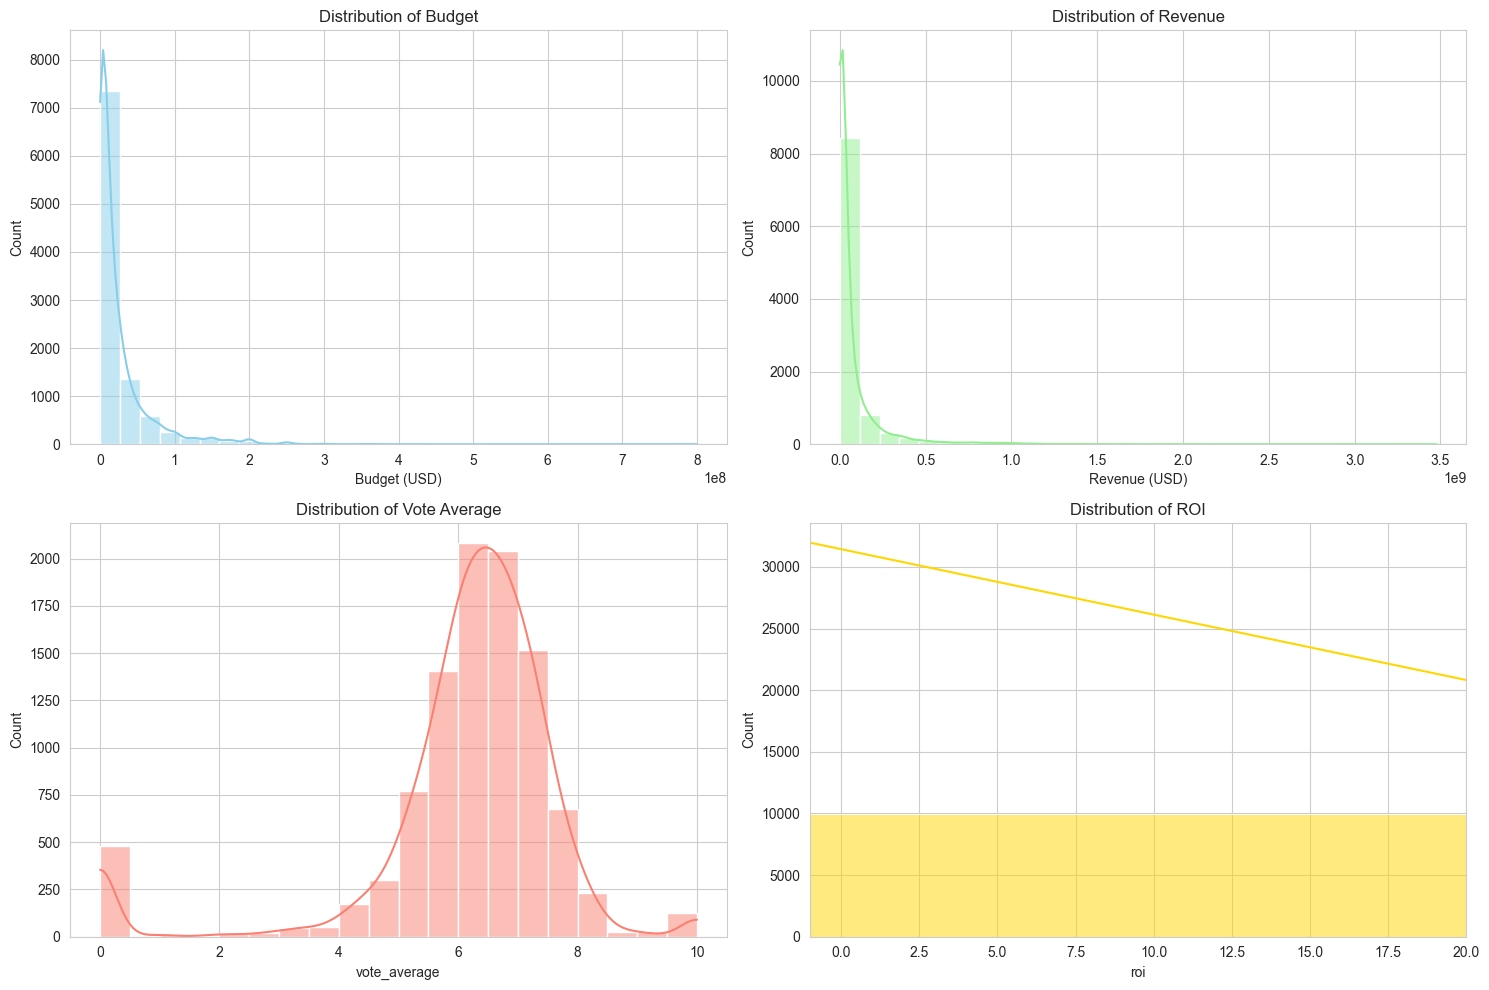

In [10]:
# 3. Distributions
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Budget
sns.histplot(df['budget'], bins=30, kde=True, ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Distribution of Budget')
axes[0,0].set_xlabel('Budget (USD)')

# Revenue
sns.histplot(df['revenue'], bins=30, kde=True, ax=axes[0,1], color='lightgreen')
axes[0,1].set_title('Distribution of Revenue')
axes[0,1].set_xlabel('Revenue (USD)')

# Vote Average
sns.histplot(df['vote_average'], bins=20, kde=True, ax=axes[1,0], color='salmon')
axes[1,0].set_title('Distribution of Vote Average')

# ROI (Limit range for visibility as outliers exist)
sns.histplot(df['roi'], bins=50, kde=True, ax=axes[1,1], color='gold')
axes[1,1].set_title('Distribution of ROI')
axes[1,1].set_xlim(-1, 20) # Focusing on common range [-100% to 2000%]

plt.tight_layout()
plt.show()

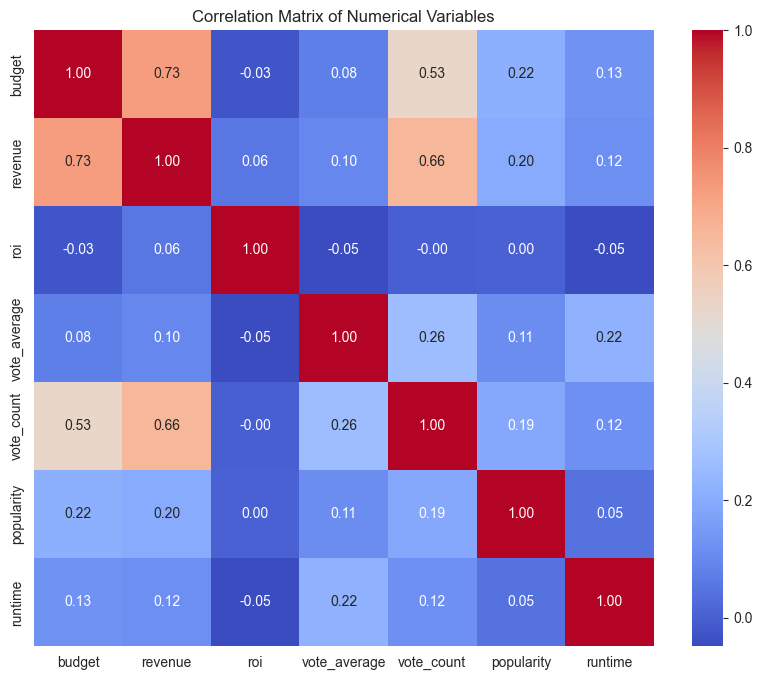

In [11]:
# 4. Correlation Heatmap
plt.figure(figsize=(10, 8))
corr = df[['budget', 'revenue', 'roi', 'vote_average', 'vote_count', 'popularity', 'runtime']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

/var/folders/yn/n87g5w9s63s668kv8lb_2hzh0000gn/T/ipykernel_88069/1483587683.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='viridis')


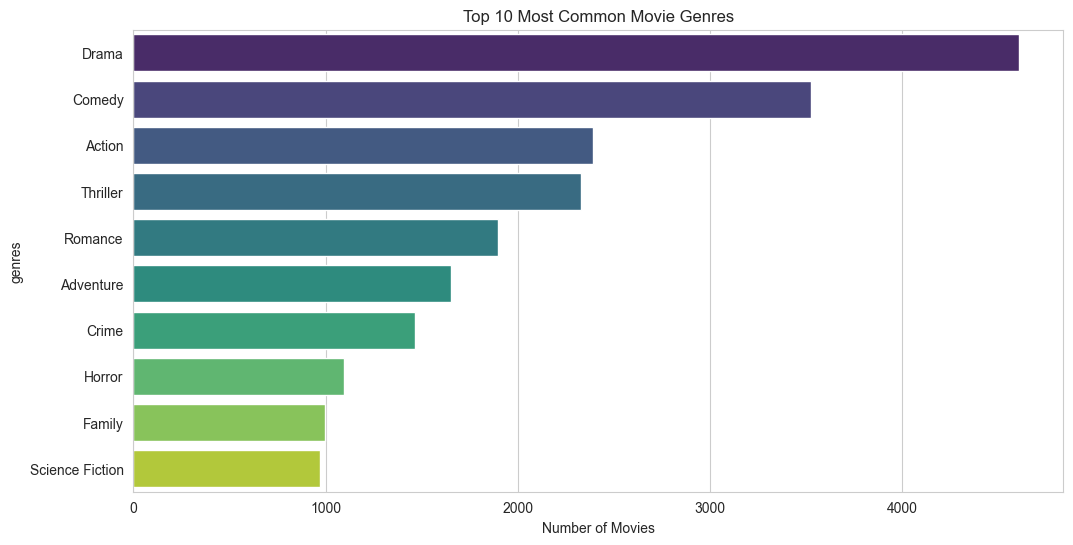

In [12]:
# 5. Top Genres (Quick Look)
# Explode the genres column to count individual genres
genre_df = df.explode('genres')
genre_counts = genre_df['genres'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='viridis')
plt.title('Top 10 Most Common Movie Genres')
plt.xlabel('Number of Movies')
plt.show()